In [ ]:
from google.colab import drive
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("Đang tải các mô hình...")
model_cnn = load_model('/content/drive/MyDrive/ensemble/weather_cnnbaseline.h5')
model_resnet = load_model('/content/drive/MyDrive/ensemble/weather_resnet50_finetuned2.h5')
model_effnet = load_model('/content/drive/MyDrive/ensemble/weather_efficientnetb3_finetuned.h5')
model_cnn_cai_tien = load_model('/content/drive/MyDrive/ensemble/weather_cnn_caitien.h5')
print("Đã tải xong tất cả mô hình!")

Đang tải các mô hình...


Đã tải xong tất cả mô hình!


In [ ]:
import tensorflow as tf
import numpy as np

DATA_DIR = "/content/drive/MyDrive/datasets/dataset"
IMG_SIZE = (300, 300)
BATCH_SIZE = 32

print("=" * 60)
print("ĐANG NẠP 20% DỮ LIỆU ĐỂ LÀM ĐỀ THI CHUNG (ENSEMBLE)")
print("=" * 60)

test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int',
    shuffle=True # Shuffle=True ở đây rất an toàn vì ta sẽ ép ra mảng Numpy ngay bên dưới
)

class_names = test_ds.class_names
print(f"\n✅ Đã nhận diện thành công {len(class_names)} nhãn: {class_names}")

# Tách dữ liệu thành mảng Numpy để đảm bảo ảnh và nhãn luôn khớp nhau 1-1
X_test = []
y_true_labels = []

for images, labels in test_ds:
    X_test.append(images.numpy())
    y_true_labels.extend(labels.numpy())
X_test = np.concatenate(X_test, axis=0)
y_true_labels = np.array(y_true_labels)

print(f"✅ Sẵn sàng! Đã nạp thành công {len(X_test)} ảnh để chạy Ensemble.")

ĐANG NẠP 20% DỮ LIỆU ĐỂ LÀM ĐỀ THI CHUNG (ENSEMBLE)
Found 6876 files belonging to 11 classes.
Using 1375 files for validation.

✅ Đã nhận diện thành công 11 nhãn: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']
✅ Sẵn sàng! Đã nạp thành công 1375 ảnh để chạy Ensemble.


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

print("⏳ Mô hình 1 (Custom CNN) đang dự đoán...")
preds_cnn = model_cnn.predict(X_test)

print("⏳ Mô hình 2 (ResNet-50) đang dự đoán...")
X_test_resnet = resnet_preprocess(X_test.copy())
preds_resnet = model_resnet.predict(X_test_resnet)

print("⏳ Mô hình 3 (EfficientNet-B3) đang dự đoán...")
# Tương tự như ResNet
X_test_effnet = effnet_preprocess(X_test.copy())
preds_effnet = model_effnet.predict(X_test_effnet)
print("⏳ Mô hình 4 (CNN Cải tiến) đang dự đoán...")
preds_cnn_caitien = model_cnn_cai_tien.predict(X_test)

print("✅ Tất cả 4 mô hình đã dự đoán xong! Chuyển sang bước kết hợp.")

⏳ Mô hình 1 (Custom CNN) đang dự đoán...
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step
⏳ Mô hình 2 (ResNet-50) đang dự đoán...
43/43 ━━━━━━━━━━━━━━━━━━━━ 24s 305ms/step
⏳ Mô hình 3 (EfficientNet-B3) đang dự đoán...
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 361ms/step
⏳ Mô hình 4 (CNN Cải tiến) đang dự đoán...
43/43 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step
✅ Tất cả 4 mô hình đã dự đoán xong! Chuyển sang bước kết hợp.


BƯỚC KẾT HỢP (WEIGHTED VOTING) VÀ ĐÁNH GIÁ (4 MÔ HÌNH)
🏆 ĐỘ CHÍNH XÁC ENSEMBLE (4 MÔ HÌNH): 92.87%

BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

         dew       0.99      0.94      0.96       132
     fogsmog       0.98      0.83      0.90       155
       frost       0.91      0.95      0.93       112
       glaze       0.88      0.94      0.91       137
        hail       0.97      1.00      0.99       105
   lightning       0.99      0.99      0.99        85
        rain       0.99      0.94      0.96       114
     rainbow       0.93      0.98      0.96        44
        rime       0.89      0.96      0.93       218
   sandstorm       0.80      0.99      0.89       133
        snow       0.99      0.78      0.87       140

    accuracy                           0.93      1375
   macro avg       0.94      0.94      0.93      1375
weighted avg       0.94      0.93      0.93      1375



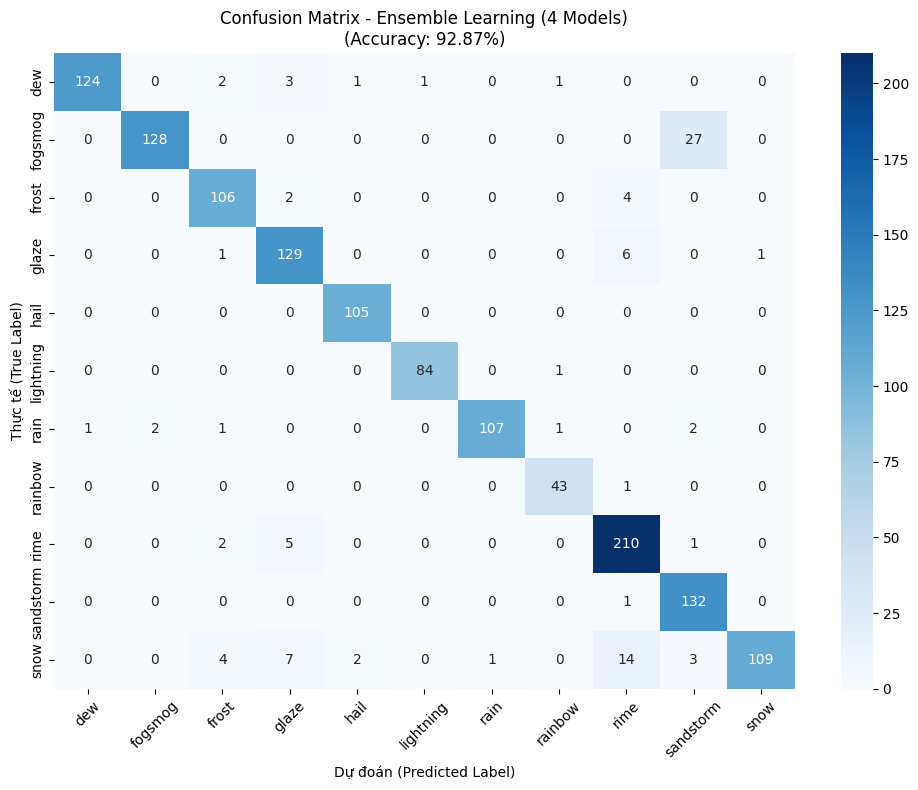

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 60)
print("BƯỚC KẾT HỢP (WEIGHTED VOTING) VÀ ĐÁNH GIÁ (4 MÔ HÌNH)")
print("=" * 60)

# 1. TÍNH TOÁN FINAL_PREDICTIONS
# Đặt trọng số cho 4 mô hình (Lưu ý: Tổng 4 số này phải bằng 1.0)
w_cnn         = 0.1  # Custom CNN ban đầu
w_resnet      = 0.25  # ResNet-50
w_effnet      = 0.4  # EfficientNet-B3
w_cnn_caitien = 0.25  # CNN Cải tiến

# Cộng dồn xác suất của CẢ 4 MÔ HÌNH
ensemble_preds = (w_cnn * preds_cnn) + \
                 (w_resnet * preds_resnet) + \
                 (w_effnet * preds_effnet) + \
                 (w_cnn_caitien * preds_cnn_caitien)

# Lấy nhãn có xác suất cao nhất làm kết quả cuối cùng
final_predictions = np.argmax(ensemble_preds, axis=1)

# 2. IN BÁO CÁO KẾT QUẢ
labels_index = np.arange(len(class_names))
accuracy = accuracy_score(y_true_labels, final_predictions)

print(f"🏆 ĐỘ CHÍNH XÁC ENSEMBLE (4 MÔ HÌNH): {accuracy * 100:.2f}%\n")
print("BÁO CÁO PHÂN LOẠI CHI TIẾT:")

print(classification_report(y_true_labels, final_predictions,
                            labels=labels_index,
                            target_names=class_names,
                            zero_division=0))

# 3. VẼ MA TRẬN NHẦM LẪN (Confusion Matrix)
cm = confusion_matrix(y_true_labels, final_predictions, labels=labels_index)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - Ensemble Learning (4 Models)\n(Accuracy: {accuracy * 100:.2f}%)')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

BƯỚC KẾT HỢP: STACKING ENSEMBLE (TENSORFLOW/KERAS)
Đã tạo Meta-features kích thước: (1375, 44)

Đang huấn luyện Meta-Model
Huấn luyện hoàn tất!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

ĐỘ CHÍNH XÁC STACKING ENSEMBLE: 94.91%

BÁO CÁO PHÂN LOẠI CHI TIẾT:
              precision    recall  f1-score   support

         dew       0.93      1.00      0.96        26
     fogsmog       1.00      1.00      1.00        31
       frost       0.91      0.91      0.91        22
       glaze       0.89      0.93      0.91        27
        hail       1.00      1.00      1.00        21
   lightning       1.00      1.00      1.00        17
        rain       0.96      0.96      0.96        23
     rainbow       1.00      1.00      1.00         9
        rime       0.93      0.91      0.92        44
   sandstorm       1.00      1.00      1.00        27
        snow       0.88      0.82      0.85        28

    accuracy                           0.95       275
   macro avg       0.95      0.96      0.96  

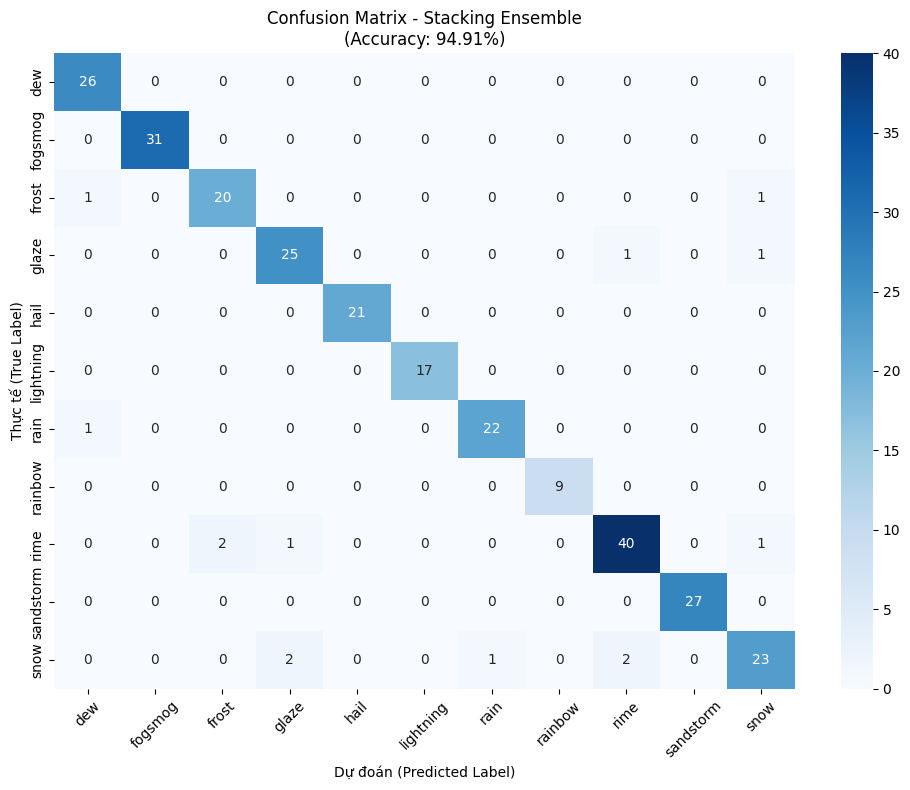

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("BƯỚC KẾT HỢP: STACKING ENSEMBLE (TENSORFLOW/KERAS)")
print("=" * 60)

# 1. GỘP CÁC DỰ ĐOÁN THÀNH META-FEATURES
# Mỗi mô hình xuất ra 11 xác suất -> 4 mô hình = 44 cột đặc trưng (features)
# Ma trận X_meta sẽ có kích thước (1375, 44)
X_meta = np.concatenate([preds_cnn, preds_resnet, preds_effnet, preds_cnn_caitien], axis=1)

print(f"Đã tạo Meta-features kích thước: {X_meta.shape}")

# 2. CHIA TẬP TRAIN/TEST CHO META-MODEL
# Tham số stratify giúp chia đều 11 loại thời tiết không bị lệch
X_meta_train, X_meta_test, y_meta_train, y_meta_test = train_test_split(
    X_meta, y_true_labels, test_size=0.2, random_state=42, stratify=y_true_labels
)

# 3. XÂY DỰNG META-MODEL BẰNG TENSORFLOW
# Một mạng nơ-ron nhỏ xíu (Multi-Layer Perceptron) làm giám khảo tối cao
meta_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(44,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Ngăn Meta-Model học vẹt
    tf.keras.layers.Dense(len(class_names), activation='softmax')
], name="Meta_Model")

meta_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. HUẤN LUYỆN META-MODEL
print("\nĐang huấn luyện Meta-Model")
history = meta_model.fit(
    X_meta_train, y_meta_train,
    epochs=50,             # Chạy 50 vòng lặp học
    batch_size=16,
    validation_data=(X_meta_test, y_meta_test),
    verbose=0              # Tắt log in ra màn hình cho gọn
)
print("Huấn luyện hoàn tất!")

# 5. DỰ ĐOÁN VÀ ĐÁNH GIÁ TRÊN TẬP TEST CỦA META-MODEL
meta_preds_probs = meta_model.predict(X_meta_test)
meta_preds_classes = np.argmax(meta_preds_probs, axis=1)

accuracy = accuracy_score(y_meta_test, meta_preds_classes)

# 6. IN BÁO CÁO
print("\n" + "=" * 50)
print(f"ĐỘ CHÍNH XÁC STACKING ENSEMBLE: {accuracy * 100:.2f}%")
print("=" * 50)

labels_index = np.arange(len(class_names))
print("\nBÁO CÁO PHÂN LOẠI CHI TIẾT:")
print(classification_report(y_meta_test, meta_preds_classes,
                            labels=labels_index,
                            target_names=class_names,
                            zero_division=0))

# 7. VẼ MA TRẬN NHẦM LẪN (Confusion Matrix)
cm = confusion_matrix(y_meta_test, meta_preds_classes, labels=labels_index)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - Stacking Ensemble\n(Accuracy: {accuracy * 100:.2f}%)')
plt.ylabel('Thực tế (True Label)')
plt.xlabel('Dự đoán (Predicted Label)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

STACKING ENSEMBLE - DECISION TREE

🏆 Accuracy Decision Tree: 93.82%

Classification Report:
              precision    recall  f1-score   support

         dew       0.93      1.00      0.96        26
     fogsmog       0.97      1.00      0.98        31
       frost       0.95      0.95      0.95        22
       glaze       0.81      0.93      0.86        27
        hail       1.00      0.95      0.98        21
   lightning       1.00      1.00      1.00        17
        rain       0.96      0.96      0.96        23
     rainbow       1.00      1.00      1.00         9
        rime       0.89      0.93      0.91        44
   sandstorm       1.00      0.96      0.98        27
        snow       0.95      0.71      0.82        28

    accuracy                           0.94       275
   macro avg       0.95      0.95      0.95       275
weighted avg       0.94      0.94      0.94       275



<Figure size 800x600 with 0 Axes>

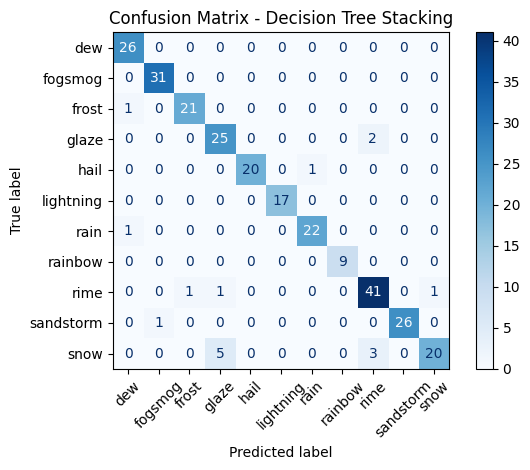

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("=" * 60)
print("STACKING ENSEMBLE - DECISION TREE")
print("=" * 60)

# Meta-Classifier
dt_meta = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# Huấn luyện
dt_meta.fit(X_meta_train, y_meta_train)

# Dự đoán
dt_preds = dt_meta.predict(X_meta_test)

# Đánh giá
dt_accuracy = accuracy_score(y_meta_test, dt_preds)

print(f"\n🏆 Accuracy Decision Tree: {dt_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_meta_test,
        dt_preds,
        target_names=class_names,
        zero_division=0
    )
)

# ==========================
# Confusion Matrix
# ==========================
cm = confusion_matrix(y_meta_test, dt_preds)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix - Decision Tree Stacking")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

STACKING ENSEMBLE - RANDOM FOREST

🏆 Accuracy Random Forest: 96.36%

Classification Report:
              precision    recall  f1-score   support

         dew       0.93      1.00      0.96        26
     fogsmog       1.00      1.00      1.00        31
       frost       0.95      0.95      0.95        22
       glaze       0.90      0.96      0.93        27
        hail       1.00      1.00      1.00        21
   lightning       1.00      1.00      1.00        17
        rain       1.00      0.96      0.98        23
     rainbow       1.00      1.00      1.00         9
        rime       0.91      0.95      0.93        44
   sandstorm       1.00      1.00      1.00        27
        snow       1.00      0.82      0.90        28

    accuracy                           0.96       275
   macro avg       0.97      0.97      0.97       275
weighted avg       0.97      0.96      0.96       275



<Figure size 800x600 with 0 Axes>

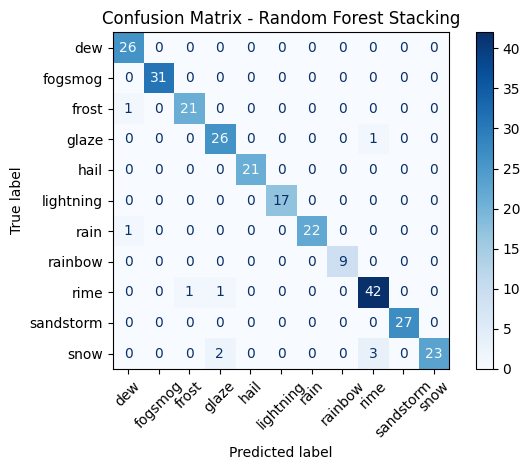

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("=" * 60)
print("STACKING ENSEMBLE - RANDOM FOREST")
print("=" * 60)

# Meta-Classifier
rf_meta = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Huấn luyện
rf_meta.fit(X_meta_train, y_meta_train)

# Dự đoán
rf_preds = rf_meta.predict(X_meta_test)

# Đánh giá
rf_accuracy = accuracy_score(y_meta_test, rf_preds)

print(f"\n🏆 Accuracy Random Forest: {rf_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        y_meta_test,
        rf_preds,
        target_names=class_names,
        zero_division=0
    )
)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Tạo confusion matrix
cm = confusion_matrix(y_meta_test, rf_preds)

# Vẽ
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    values_format='d'
)

plt.title('Confusion Matrix - Random Forest Stacking')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
results = {
    "MLP Meta-Classifier": accuracy,
    "Decision Tree": dt_accuracy,
    "Random Forest": rf_accuracy
}

print("=" * 50)
print("SO SÁNH CÁC META-CLASSIFIER")
print("=" * 50)

for name, acc in results.items():
    print(f"{name:<25}: {acc*100:.2f}%")

SO SÁNH CÁC META-CLASSIFIER
MLP Meta-Classifier      : 94.91%
Decision Tree            : 93.82%
Random Forest            : 96.36%


In [ ]:
import joblib
import json
from google.colab import files

print("Đang lưu tất cả mô hình và cấu hình...")

# 1. Lưu 4 mô hình gốc (Bắt buộc cho mọi Ensemble)
model_cnn.save('model_cnn.h5')
model_resnet.save('model_resnet.h5')
model_effnet.save('model_effnet.h5')
model_cnn_cai_tien.save('model_cnn_caitien.h5')

# 2. Lưu Ensemble 1 - Weighted Voting
voting_weights = {
    "w_cnn": 0.1,
    "w_resnet": 0.25,
    "w_effnet": 0.4,
    "w_cnn_caitien": 0.25
}
with open('weighted_voting_config.json', 'w') as f:
    json.dump(voting_weights, f)

# 3. Lưu Ensemble 2, 3, 4 - Stacking Models
meta_model.save('meta_model_mlp.h5')
joblib.dump(dt_meta, 'meta_model_dt.pkl')
joblib.dump(rf_meta, 'meta_model_rf.pkl')

print("✅ Đã lưu xong, đang tiến hành tải về máy tính...")

# 4. Tải về máy tính
files_to_download = [
    'model_cnn.h5',
    'model_resnet.h5',
    'model_effnet.h5',
    'model_cnn_caitien.h5',
    'weighted_voting_config.json',
    'meta_model_mlp.h5',
    'meta_model_dt.pkl',
    'meta_model_rf.pkl'
]

for file_name in files_to_download:
    files.download(file_name)



Đang lưu tất cả mô hình và cấu hình...


✅ Đã lưu xong, đang tiến hành tải về máy tính...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>